# Notebook 10: Function Approximation in RL

**Series:** Reinforcement Learning Basics (10/20)

---

## 1. Why Function Approximation?

Tabular methods need a separate entry for each state. Real-world problems have:
- **Continuous** state spaces (robot joint angles)
- **Huge** discrete spaces (Go: $3^{361}$ states)

**Solution:** Approximate $V(s) \approx \hat{V}(s, \mathbf{w})$ with a parameterized function.

## 2. Linear Function Approximation

$$\hat{V}(s, \mathbf{w}) = \mathbf{w}^\top \mathbf{x}(s) = \sum_{j=1}^d w_j x_j(s)$$

where $\mathbf{x}(s) = [x_1(s), \ldots, x_d(s)]^\top$ is a **feature vector**.

### Objective: Mean Squared Value Error
$$\overline{VE}(\mathbf{w}) = \sum_s \mu(s) \Big[ V^\pi(s) - \hat{V}(s, \mathbf{w}) \Big]^2$$

### SGD Update
$$\mathbf{w} \leftarrow \mathbf{w} + \alpha \Big[ V^\pi(S_t) - \hat{V}(S_t, \mathbf{w}) \Big] \nabla_\mathbf{w} \hat{V}(S_t, \mathbf{w})$$

For linear: $\nabla_\mathbf{w} \hat{V}(S_t, \mathbf{w}) = \mathbf{x}(S_t)$

### Semi-Gradient TD(0)
$$\mathbf{w} \leftarrow \mathbf{w} + \alpha \Big[ R_{t+1} + \gamma \hat{V}(S_{t+1}, \mathbf{w}) - \hat{V}(S_t, \mathbf{w}) \Big] \nabla_\mathbf{w} \hat{V}(S_t, \mathbf{w})$$

**"Semi-gradient"** because we don't differentiate through the target $\hat{V}(S_{t+1}, \mathbf{w})$.

## 3. Feature Construction

| Method | Features | Properties |
|--------|----------|------------|
| **Polynomial** | $1, s, s^2, \ldots$ | Simple, global |
| **Fourier** | $\cos(k\pi s)$ | Smooth, global |
| **Tile Coding** | Binary, overlapping tiles | Local, efficient |
| **RBF** | $\exp(-\|s - c_j\|^2 / 2\sigma^2)$ | Local, smooth |

## 4. Convergence

For linear function approximation with semi-gradient TD(0):
$$\overline{VE}(\mathbf{w}_{TD}) \leq \frac{1}{1 - \gamma} \min_\mathbf{w} \overline{VE}(\mathbf{w})$$

The TD solution is within a factor of $\frac{1}{1-\gamma}$ of the best possible linear approximation.

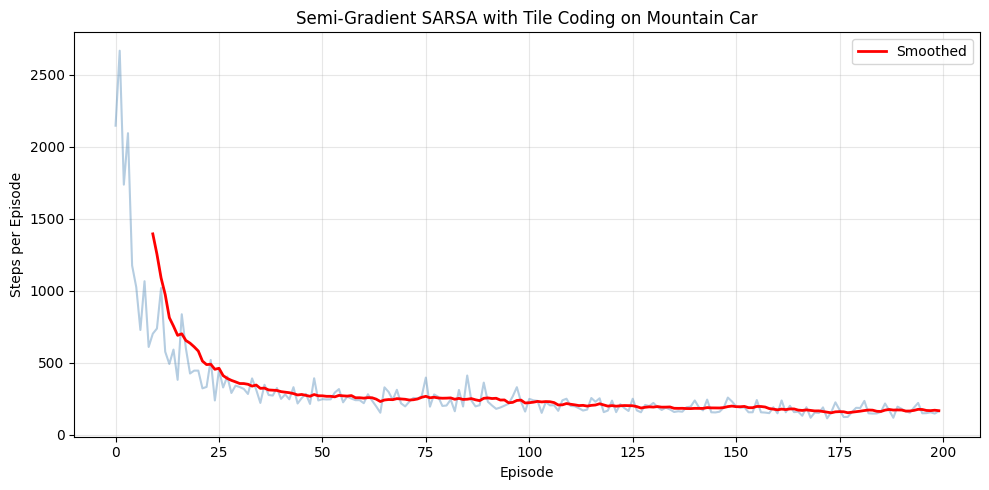

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# Tile Coding Implementation
# ============================================
class TileCoding:
    def __init__(self, n_tilings=8, tiles_per_dim=8, state_bounds=None):
        self.n_tilings = n_tilings
        self.tiles_per_dim = tiles_per_dim
        self.state_bounds = state_bounds  # list of (low, high) for each dim
        self.n_dims = len(state_bounds)
        self.n_tiles = n_tilings * (tiles_per_dim ** self.n_dims)

    def get_features(self, state):
        features = np.zeros(self.n_tiles)
        for tiling in range(self.n_tilings):
            indices = []
            for dim in range(self.n_dims):
                low, high = self.state_bounds[dim]
                width = (high - low) / self.tiles_per_dim
                offset = tiling * width / self.n_tilings
                idx = int((state[dim] - low + offset) / width)
                idx = max(0, min(self.tiles_per_dim - 1, idx))
                indices.append(idx)
            # Flatten multi-dim index
            flat_idx = tiling * (self.tiles_per_dim ** self.n_dims)
            for d, idx in enumerate(indices):
                flat_idx += idx * (self.tiles_per_dim ** (self.n_dims - 1 - d))
            features[flat_idx] = 1.0
        return features

# ============================================
# Mountain Car with Semi-Gradient SARSA
# ============================================
class MountainCar:
    def __init__(self):
        self.pos_bounds = (-1.2, 0.5)
        self.vel_bounds = (-0.07, 0.07)

    def reset(self):
        self.pos = np.random.uniform(-0.6, -0.4)
        self.vel = 0.0
        return (self.pos, self.vel)

    def step(self, action):
        # action: 0=reverse, 1=neutral, 2=forward
        force = action - 1  # -1, 0, or 1
        self.vel += 0.001 * force - 0.0025 * np.cos(3 * self.pos)
        self.vel = np.clip(self.vel, *self.vel_bounds)
        self.pos += self.vel
        self.pos = np.clip(self.pos, *self.pos_bounds)
        if self.pos == self.pos_bounds[0]:
            self.vel = 0.0
        done = self.pos >= 0.5
        return (self.pos, self.vel), -1.0, done

# Train
env = MountainCar()
tc = TileCoding(n_tilings=8, tiles_per_dim=8,
                state_bounds=[(-1.2, 0.5), (-0.07, 0.07)])

n_actions = 3
w = np.zeros((n_actions, tc.n_tiles))
alpha = 0.1 / 8  # divide by n_tilings
gamma = 1.0
epsilon = 0.1

def get_q(state, action):
    return np.dot(w[action], tc.get_features(state))

def choose_action(state):
    if np.random.random() < epsilon:
        return np.random.randint(n_actions)
    qs = [get_q(state, a) for a in range(n_actions)]
    return np.argmax(qs)

steps_per_episode = []
for ep in range(200):
    state = env.reset()
    action = choose_action(state)
    steps = 0
    for _ in range(5000):
        next_state, reward, done = env.step(action)
        steps += 1
        if done:
            w[action] += alpha * (reward - get_q(state, action)) * tc.get_features(state)
            break
        next_action = choose_action(next_state)
        td_error = reward + gamma * get_q(next_state, next_action) - get_q(state, action)
        w[action] += alpha * td_error * tc.get_features(state)
        state, action = next_state, next_action
    steps_per_episode.append(steps)

plt.figure(figsize=(10, 5))
plt.plot(steps_per_episode, alpha=0.4, color='steelblue')
window = 10
smoothed = np.convolve(steps_per_episode, np.ones(window)/window, mode='valid')
plt.plot(range(window-1, len(steps_per_episode)), smoothed, 'r-', linewidth=2, label='Smoothed')
plt.xlabel('Episode')
plt.ylabel('Steps per Episode')
plt.title('Semi-Gradient SARSA with Tile Coding on Mountain Car')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

| Concept | Formula |
|---------|---------|
| **Linear Approximation** | $\hat{V}(s,\mathbf{w}) = \mathbf{w}^\top \mathbf{x}(s)$ |
| **Semi-Gradient TD** | $\mathbf{w} \leftarrow \mathbf{w} + \alpha \delta_t \nabla_\mathbf{w} \hat{V}(S_t, \mathbf{w})$ |
| **TD Error** | $\delta_t = R_{t+1} + \gamma \hat{V}(S_{t+1}, \mathbf{w}) - \hat{V}(S_t, \mathbf{w})$ |

**Next:** Notebook 11 — Policy Gradient Methods